In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Load data
df = pd.read_csv('../dataset/track_data_final.csv')

# Show first 5 rows
df.head(5)

,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,158463,True,Billie Eilish,90.0,118692183.0,[],0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,267013,False,Rihanna,90.0,68997177.0,[],5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album


### Data Dictionary

| Column | Meaning | Example |
|---|---|---|
| `track_id` | Unique ID for the track | `6pymOcrCnMuCWdgGVTvUgP` |
| `track_name` | Name of the track | `3` |
| `track_number` | Track number in the album | `57` |
| `track_popularity` | Popularity score (0-100) | `61` |
| `track_duration_ms` | Duration in milliseconds | `213173` |
| `explicit` | Explicit content flag | `False` |
| `artist_name` | Name of the artist | `Britney Spears` |
| `artist_popularity` | Artist popularity score | `80.0` |
| `artist_followers` | Number of artist followers | `17755451.0` |
| `artist_genres` | Genres associated with artist | `['pop']` |
| `album_id` | Unique ID for the album | `325wcm5wMnlfjmKZ8PXIIn` |
| `album_name` | Name of the album | `The Singles Collection` |
| `album_release_date` | Release date of the album | `2009-11-09` |
| `album_total_tracks` | Total tracks in the album | `58` |
| `album_type` | Type of album (album, single, etc.) | `compilation` |

## Phân tích ảnh hưởng của Album Type đến Popularity

In [13]:
# Kiểm tra các loại album_type có trong dataset
print("Các loại Album Type:")
print(df['album_type'].value_counts())

Các loại Album Type:
album_type
album          6022
single         2248
compilation     508
Name: count, dtype: int64


## Tổng quan So sánh Album Type

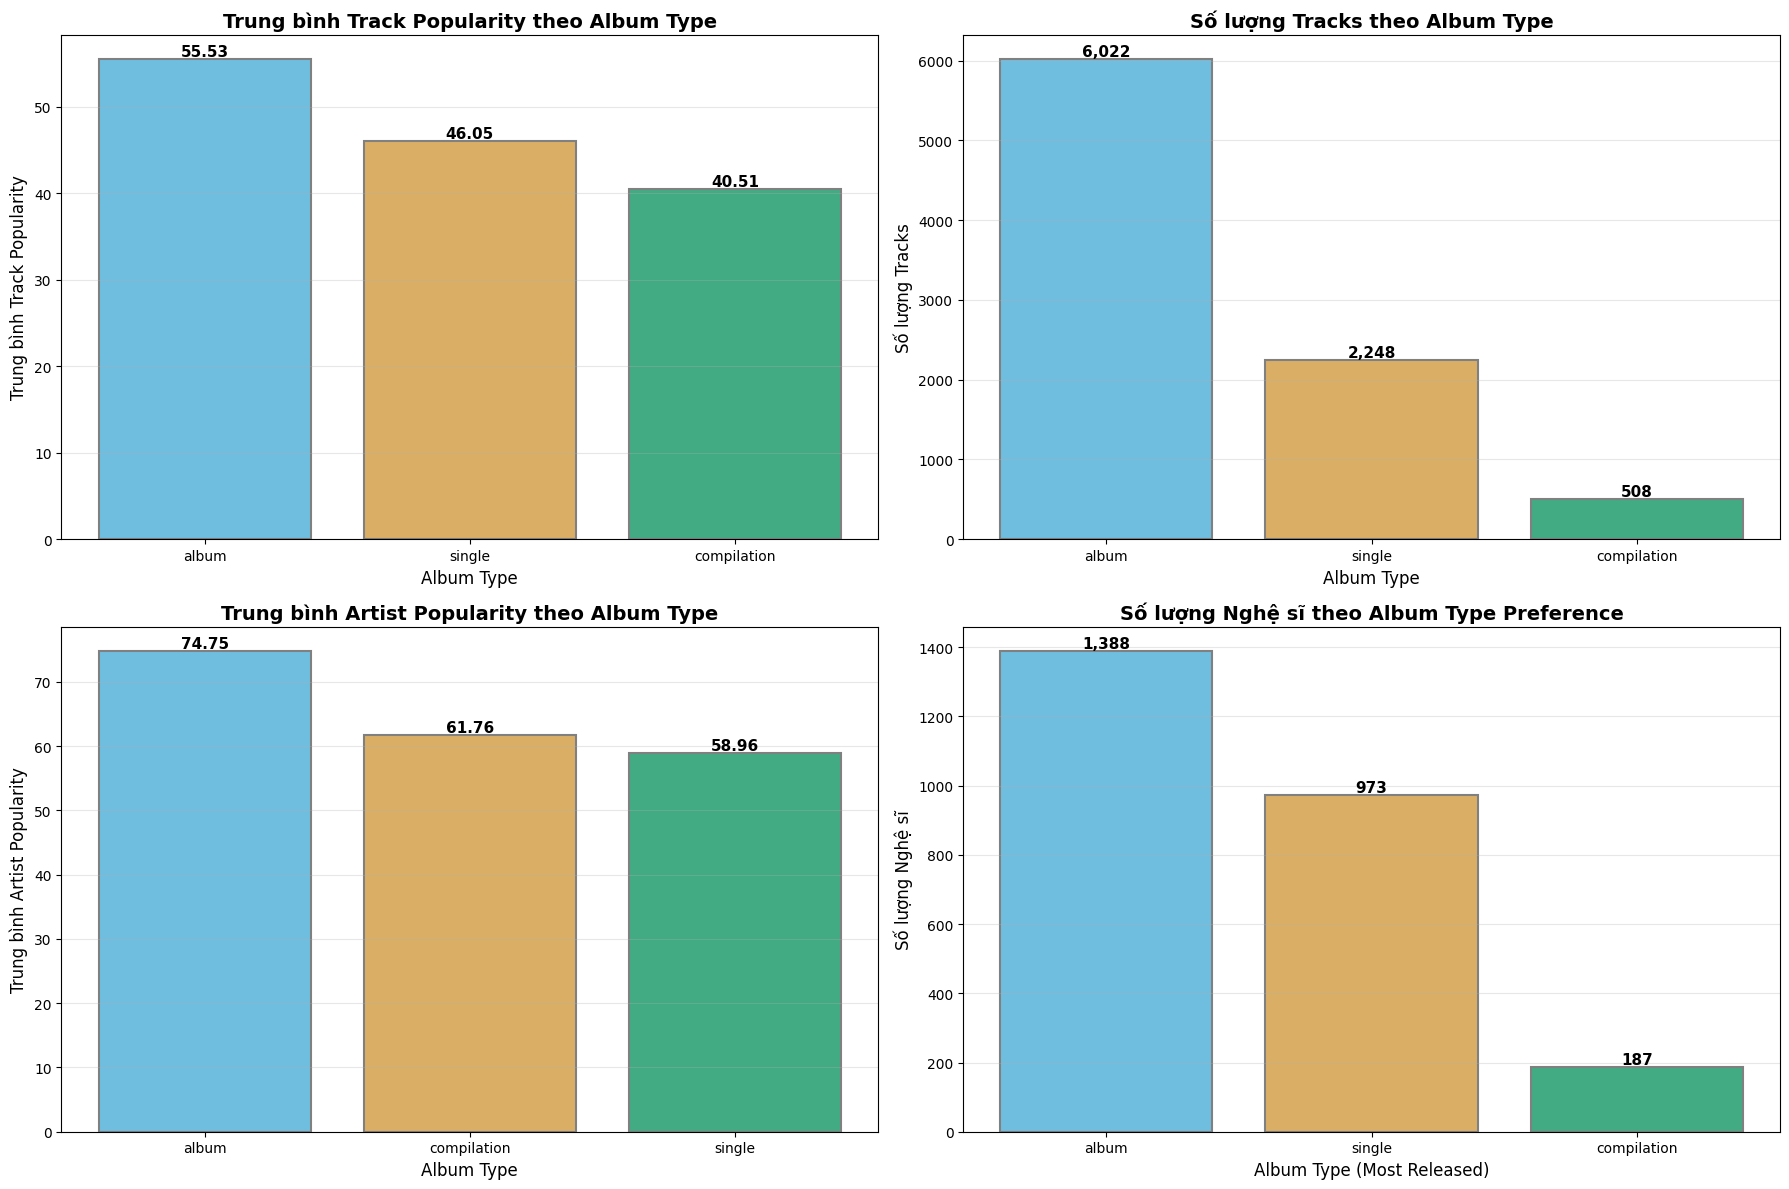


TỔNG HỢP THỐNG KÊ THEO ALBUM TYPE
             Track Popularity (Mean)  Artist Popularity (Mean)  Số Tracks  \
album_type                                                                  
album                          55.53                     74.75       6022   
compilation                    40.51                     61.76        508   
single                         46.05                     58.96       2248   

             Số Artists  
album_type               
album              1388  
compilation         187  
single              973  


In [ ]:
# Tổng quan So sánh các chỉ số theo Album Type
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Bar chart - Trung bình Track Popularity
avg_pop_data = df.groupby('album_type')['track_popularity'].mean().sort_values(ascending=False)
bars1 = axes[0, 0].bar(avg_pop_data.index, avg_pop_data.values, 
                       color=["#6FBEE0", "#DAAF65", "#42AB84"], 
                       edgecolor='gray', linewidth=1.5)
axes[0, 0].set_title('Trung bình Track Popularity theo Album Type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Album Type', fontsize=12)
axes[0, 0].set_ylabel('Trung bình Track Popularity', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Thêm giá trị
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Count plot - Số lượng Tracks theo album_type
count_data = df['album_type'].value_counts()
bars2 = axes[0, 1].bar(count_data.index, count_data.values, 
                       color=['#6FBEE0', '#DAAF65', '#42AB84'], 
                       edgecolor='gray', linewidth=1.5)
axes[0, 1].set_title('Số lượng Tracks theo Album Type', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Album Type', fontsize=12)
axes[0, 1].set_ylabel('Số lượng Tracks', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Thêm giá trị
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. Bar Chart - Mean Artist Popularity
avg_artist_pop = df.groupby('album_type')['artist_popularity'].mean().sort_values(ascending=False)
bars3 = axes[1, 0].bar(avg_artist_pop.index, avg_artist_pop.values, 
                       color=['#6FBEE0', '#DAAF65', '#42AB84'], 
                       edgecolor='gray', linewidth=1.5)
axes[1, 0].set_title('Trung bình Artist Popularity theo Album Type', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Album Type', fontsize=12)
axes[1, 0].set_ylabel('Trung bình Artist Popularity', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Thêm giá trị
for bar in bars3:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Count - Số nghệ sĩ theo album_type preference
artist_album_pref = df.groupby(['artist_name', 'album_type']).size().reset_index(name='count')
artist_dominant_type = artist_album_pref.loc[artist_album_pref.groupby('artist_name')['count'].idxmax()]
type_counts = artist_dominant_type['album_type'].value_counts()

bars4 = axes[1, 1].bar(type_counts.index, type_counts.values, 
                       color=['#6FBEE0', '#DAAF65', '#42AB84'], 
                       edgecolor='gray', linewidth=1.5)
axes[1, 1].set_title('Số lượng Nghệ sĩ theo Album Type Preference', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Album Type (Most Released)', fontsize=12)
axes[1, 1].set_ylabel('Số lượng Nghệ sĩ', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Thêm giá trị
for bar in bars4:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\LIANLI\AppData\Local\Temp\ipykernel_6192\1098139863.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='album_type', y='artist_popularity', ax=axes[0, 0],
C:\Users\LIANLI\AppData\Local\Temp\ipykernel_6192\1098139863.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='album_type', y='track_popularity', ax=axes[0, 1],
C:\Users\LIANLI\AppData\Local\Temp\ipykernel_6192\1098139863.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='album_type', y='artist_popularity', ax=axes[1, 0],
C:\Users\LIANLI

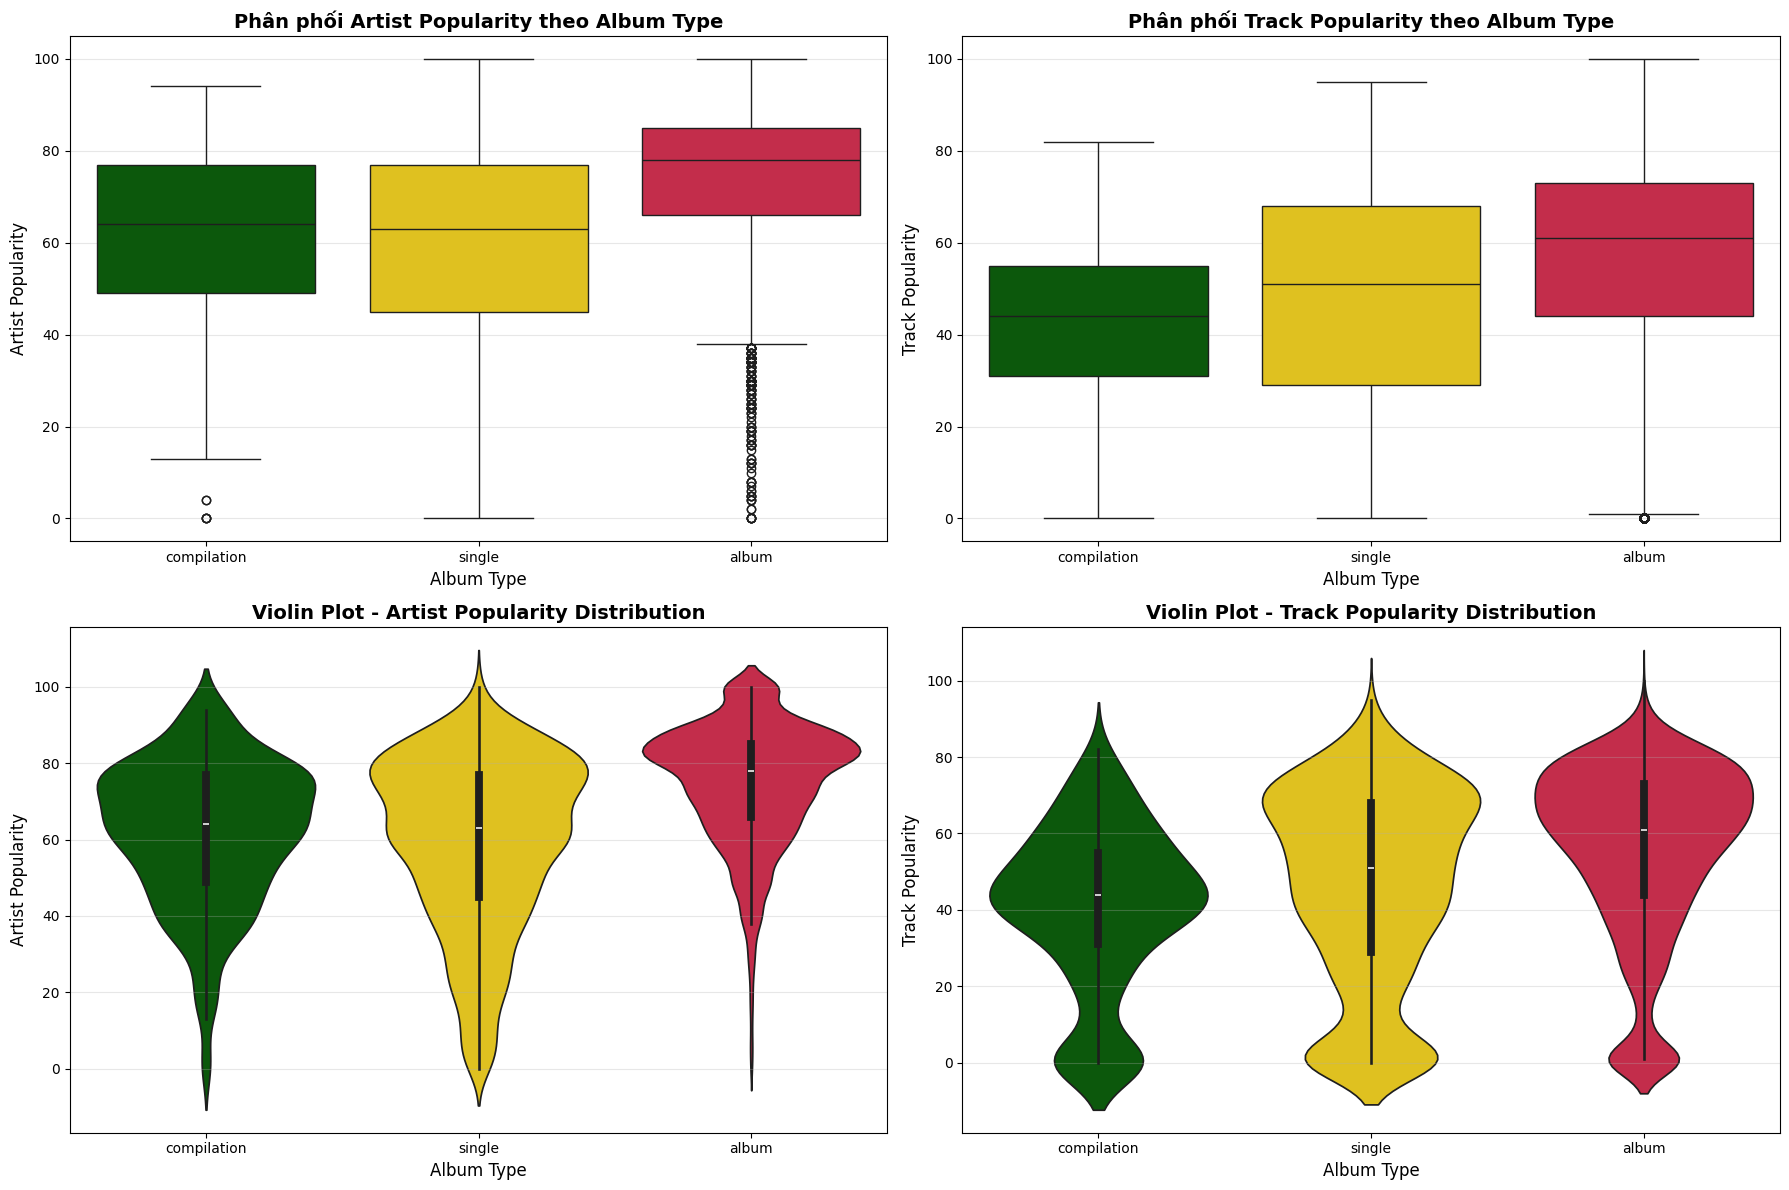


THỐNG KÊ MÔ TẢ ARTIST POPULARITY
              count   mean    std  min   25%   50%   75%    max
album_type                                                     
album        6020.0  74.75  16.18  0.0  66.0  78.0  85.0  100.0
compilation   508.0  61.76  18.75  0.0  49.0  64.0  77.0   94.0
single       2246.0  58.96  22.62  0.0  45.0  63.0  77.0  100.0

THỐNG KÊ MÔ TẢ TRACK POPULARITY
              count   mean    std  min   25%   50%   75%    max
album_type                                                     
album        6022.0  55.53  22.90  0.0  44.0  61.0  73.0  100.0
compilation   508.0  40.51  21.46  0.0  31.0  44.0  55.0   82.0
single       2248.0  46.05  25.62  0.0  29.0  51.0  68.0   95.0


In [ ]:
# Phân phối Popularity - Box Plot & Violin Plot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

colors_palette = {'album': '#DC143C', 'single': '#FFD700', 'compilation': '#006400'}

# 1. Box Plot - Artist Popularity theo Album Type
axes[0, 0].set_title('Phân phối Artist Popularity theo Album Type', fontsize=14, fontweight='bold')
sns.boxplot(data=df, x='album_type', y='artist_popularity', ax=axes[0, 0], 
            palette=[colors_palette.get(x, 'gray') for x in df['album_type'].unique()])
axes[0, 0].set_xlabel('Album Type', fontsize=12)
axes[0, 0].set_ylabel('Artist Popularity', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Box Plot - Track Popularity theo Album Type
axes[0, 1].set_title('Phân phối Track Popularity theo Album Type', fontsize=14, fontweight='bold')
sns.boxplot(data=df, x='album_type', y='track_popularity', ax=axes[0, 1],
            palette=[colors_palette.get(x, 'gray') for x in df['album_type'].unique()])
axes[0, 1].set_xlabel('Album Type', fontsize=12)
axes[0, 1].set_ylabel('Track Popularity', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Violin Plot - Artist Popularity Distribution
axes[1, 0].set_title('Violin Plot - Artist Popularity Distribution', fontsize=14, fontweight='bold')
sns.violinplot(data=df, x='album_type', y='artist_popularity', ax=axes[1, 0],
               palette=[colors_palette.get(x, 'gray') for x in df['album_type'].unique()])
axes[1, 0].set_xlabel('Album Type', fontsize=12)
axes[1, 0].set_ylabel('Artist Popularity', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Violin Plot - Track Popularity Distribution
axes[1, 1].set_title('Violin Plot - Track Popularity Distribution', fontsize=14, fontweight='bold')
sns.violinplot(data=df, x='album_type', y='track_popularity', ax=axes[1, 1],
               palette=[colors_palette.get(x, 'gray') for x in df['album_type'].unique()])
axes[1, 1].set_xlabel('Album Type', fontsize=12)
axes[1, 1].set_ylabel('Track Popularity', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [16]:
# Chuẩn bị dữ liệu cho phân tích xu hướng
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Tạo cột release_year từ album_release_date
df['release_year'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce').dt.year

# Dữ liệu unique albums (mỗi album chỉ đếm 1 lần)
df_unique_albums = df.drop_duplicates(subset=['album_id'])

# Artist popularity theo năm và album_type (từ unique albums)
yearly_artist_pop = df_unique_albums.groupby(['release_year', 'album_type'])['artist_popularity'].mean().reset_index()

# Số albums duy nhất theo năm và album_type
yearly_album_count = df_unique_albums.groupby(['release_year', 'album_type']).size().reset_index(name='album_count')

# Số nghệ sĩ duy nhất theo năm và album_type
yearly_artist_count = df.groupby(['release_year', 'album_type'])['artist_name'].nunique().reset_index(name='artist_count')

# Số tracks theo năm và album_type
yearly_counts = df.groupby(['release_year', 'album_type']).size().reset_index(name='track_count')

print("✓ Dữ liệu đã được chuẩn bị!")
print(f"  - Tổng số năm: {df['release_year'].nunique()}")
print(f"  - Năm sớm nhất: {int(df['release_year'].min())}")
print(f"  - Năm gần nhất: {int(df['release_year'].max())}")
print(f"  - Tổng số unique albums: {len(df_unique_albums):,}")
print(f"  - Tổng số tracks: {len(df):,}")

✓ Dữ liệu đã được chuẩn bị!
  - Tổng số năm: 68
  - Năm sớm nhất: 1952
  - Năm gần nhất: 2025
  - Tổng số unique albums: 5,317
  - Tổng số tracks: 8,778


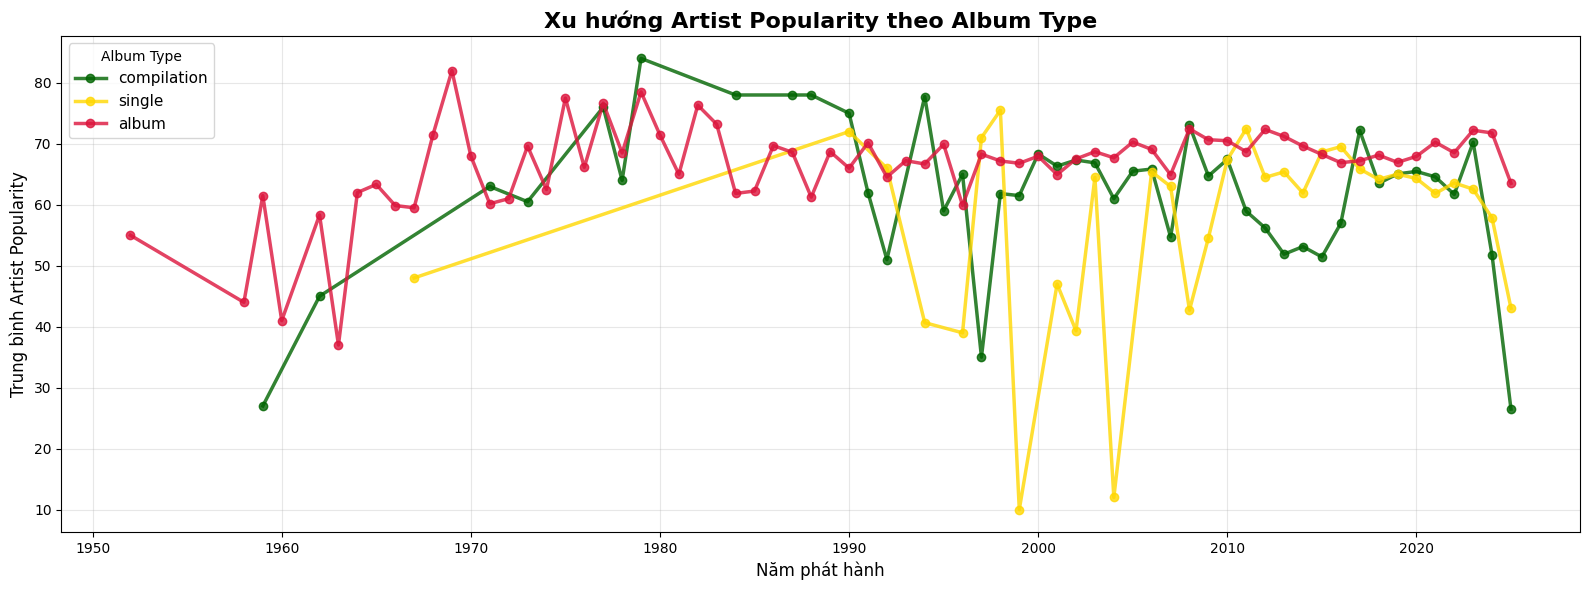

In [17]:
# Xu hướng Artist Popularity theo Album Type qua các Năm
plt.figure(figsize=(16, 6))

colors_line = {'album': '#DC143C', 'single': '#FFD700', 'compilation': '#006400'}

for album_type in df['album_type'].unique():
    data = yearly_artist_pop[yearly_artist_pop['album_type'] == album_type]
    plt.plot(data['release_year'], data['artist_popularity'], 
             marker='o', label=album_type, linewidth=2.5, markersize=6, 
             color=colors_line.get(album_type, 'gray'), alpha=0.8)

plt.title('Xu hướng Artist Popularity theo Album Type', fontsize=16, fontweight='bold')
plt.xlabel('Năm phát hành', fontsize=12)
plt.ylabel('Trung bình Artist Popularity', fontsize=12)
plt.legend(title='Album Type', fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

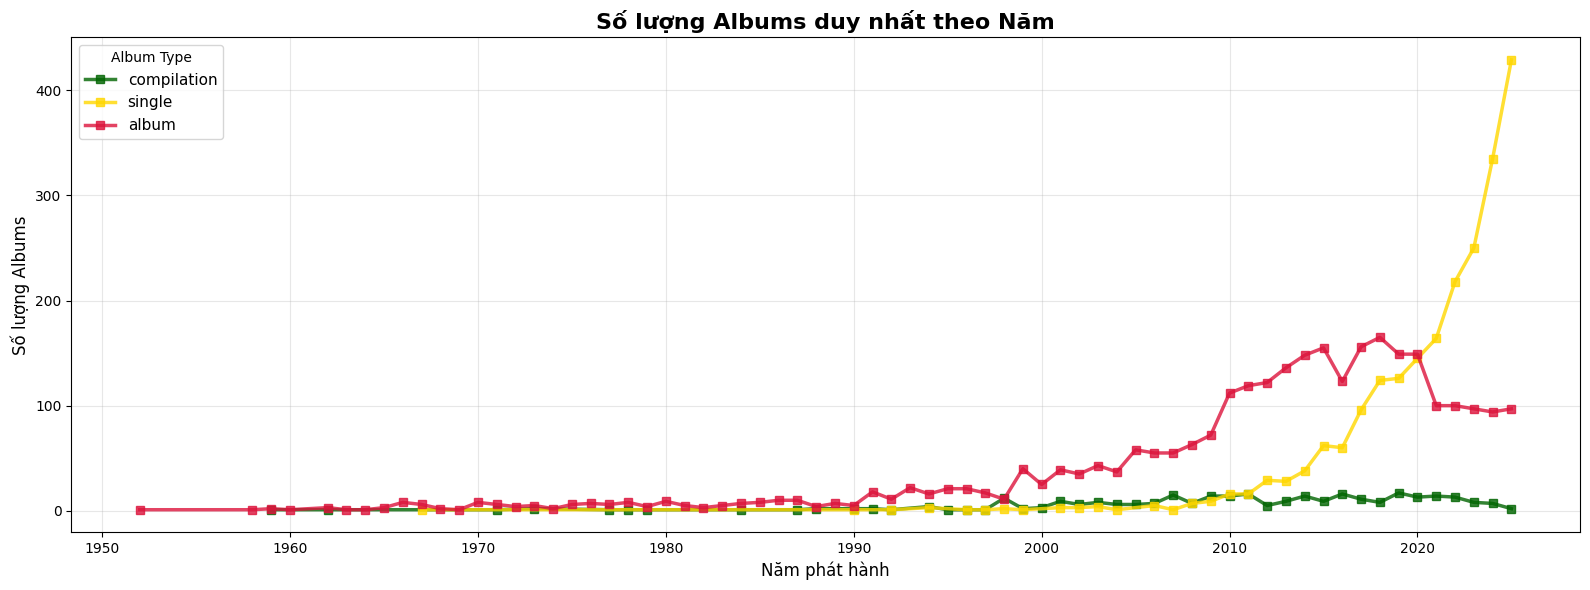

In [18]:
# Số lượng Albums duy nhất theo Năm
plt.figure(figsize=(16, 6))

colors_line = {'album': '#DC143C', 'single': '#FFD700', 'compilation': '#006400'}

for album_type in df['album_type'].unique():
    data = yearly_album_count[yearly_album_count['album_type'] == album_type]
    plt.plot(data['release_year'], data['album_count'], 
             marker='s', label=album_type, linewidth=2.5, markersize=6, 
             color=colors_line.get(album_type, 'gray'), alpha=0.8)

plt.title('Số lượng Albums duy nhất theo Năm', fontsize=16, fontweight='bold')
plt.xlabel('Năm phát hành', fontsize=12)
plt.ylabel('Số lượng Albums', fontsize=12)
plt.legend(title='Album Type', fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

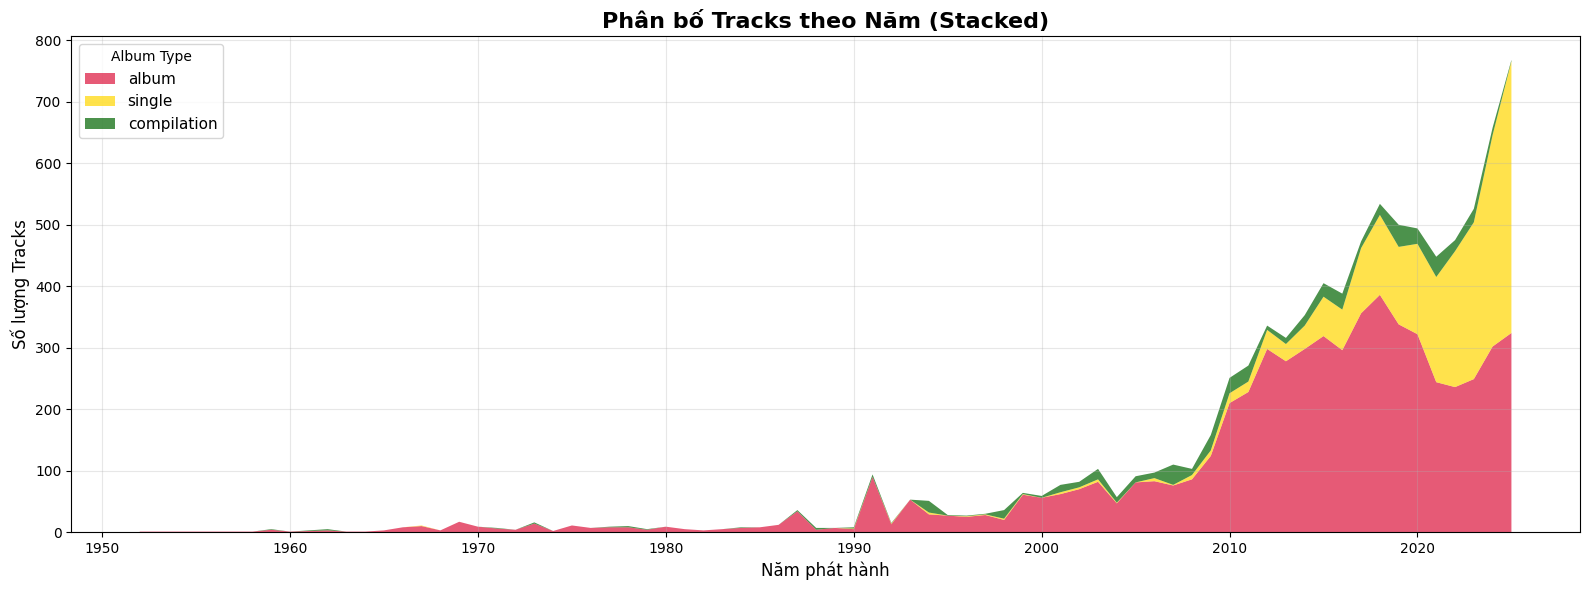

In [19]:
# Stacked Area Chart - Phân bố Tracks theo Năm
plt.figure(figsize=(16, 6))

colors_line = {'album': '#DC143C', 'single': '#FFD700', 'compilation': '#006400'}

yearly_pivot = yearly_counts.pivot(index='release_year', columns='album_type', values='track_count').fillna(0)

# Sắp xếp cột theo thứ tự album, single, compilation để colors nhất quán
column_order = ['album', 'single', 'compilation']
yearly_pivot = yearly_pivot[[col for col in column_order if col in yearly_pivot.columns]]

plt.stackplot(yearly_pivot.index, 
              [yearly_pivot[col] for col in yearly_pivot.columns],
              labels=yearly_pivot.columns,
              colors=[colors_line.get(col, 'gray') for col in yearly_pivot.columns],
              alpha=0.7)

plt.title('Phân bố Tracks theo Năm (Stacked)', fontsize=16, fontweight='bold')
plt.xlabel('Năm phát hành', fontsize=12)
plt.ylabel('Số lượng Tracks', fontsize=12)
plt.legend(title='Album Type', fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

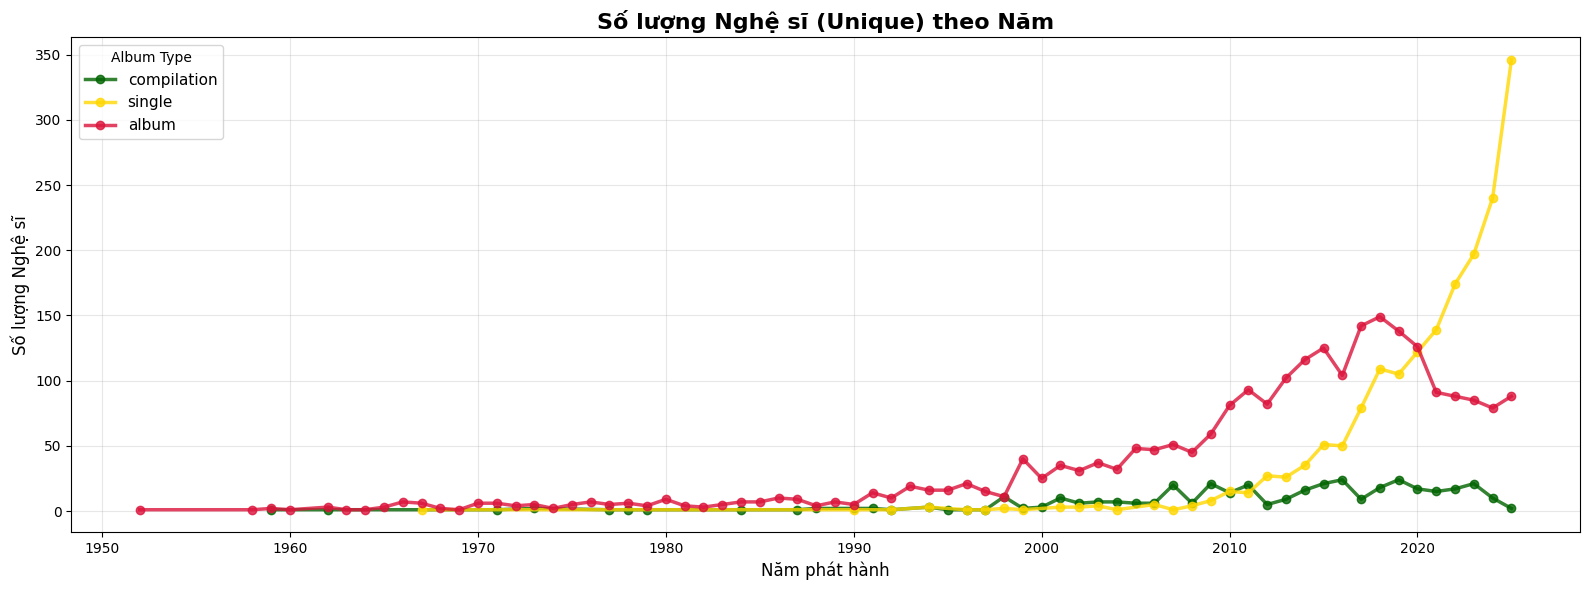


Artist Popularity (Mean):
album_type    album  compilation  single
release_year                            
2015.0        68.25        51.44   68.66
2016.0        66.90        56.94   69.53
2017.0        67.21        72.18   65.88
2018.0        68.14        63.50   64.16
2019.0        66.95        65.06   65.02
2020.0        67.93        65.46   64.31
2021.0        70.25        64.57   61.85
2022.0        68.53        61.69   63.58
2023.0        72.22        70.25   62.55
2024.0        71.78        51.71   57.84
2025.0        63.52        26.50   43.05

Số Albums duy nhất:
album_type    album  compilation  single
release_year                            
2015.0          155            9      62
2016.0          123           16      60
2017.0          156           11      96
2018.0          165            8     124
2019.0          149           17     126
2020.0          149           13     145
2021.0          100           14     164
2022.0          100           13     218
2023.0   

In [20]:
# Số lượng Nghệ sĩ (Unique) theo Năm
plt.figure(figsize=(16, 6))

colors_line = {'album': '#DC143C', 'single': '#FFD700', 'compilation': '#006400'}

for album_type in df['album_type'].unique():
    data = yearly_artist_count[yearly_artist_count['album_type'] == album_type]
    plt.plot(data['release_year'], data['artist_count'], 
             marker='o', label=album_type, linewidth=2.5, markersize=6, 
             color=colors_line.get(album_type, 'gray'), alpha=0.8)

plt.title('Số lượng Nghệ sĩ (Unique) theo Năm', fontsize=16, fontweight='bold')
plt.xlabel('Năm phát hành', fontsize=12)
plt.ylabel('Số lượng Nghệ sĩ', fontsize=12)
plt.legend(title='Album Type', fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Thống kê 10 năm gần nhất
recent_10_years = df['release_year'].max() - 10

print("\nArtist Popularity (Mean):")
recent_artist_trend = yearly_artist_pop[yearly_artist_pop['release_year'] >= recent_10_years]
print(recent_artist_trend.pivot(index='release_year', columns='album_type', values='artist_popularity').round(2))

print("\nSố Albums duy nhất:")
recent_album_counts = yearly_album_count[yearly_album_count['release_year'] >= recent_10_years]
print(recent_album_counts.pivot(index='release_year', columns='album_type', values='album_count').fillna(0).astype(int))

print("\nSố Nghệ sĩ duy nhất:")
recent_artist_counts = yearly_artist_count[yearly_artist_count['release_year'] >= recent_10_years]
print(recent_artist_counts.pivot(index='release_year', columns='album_type', values='artist_count').fillna(0).astype(int))